# Simple model training

Let's train simple ML models with our data in order to develop a robust model capable of accurately predicting SWF.

### Library loading

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import time
import optuna
import shap
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from tqdm import tqdm

import json
from pathlib import Path

from CIMR.SurfaceWaterFraction_ATBD_main.algorithm.processing.validation_data_processing import load_lut, unravel_freqpol, atmospheric_corrections

from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error, make_scorer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import xgboost as xgb

time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)

### Data setup

We'll train the models with the previous merged datasets.

In [2]:
df = pd.read_parquet("data/windsat_2017")

In [3]:
features_1 = [
    "tbboa_de_lannoy19H",
    "surtep_ERA5",
]

features_2 = [
    "tbtoa19H",
    "surtep_ERA5",
    "tran19H",
    "tbup19H",
    "tbdw19H",
]

features_3 = [
    "tbboa_de_lannoy19H",
    "tbboa_de_lannoy19V",
    "surtep_ERA5",
    "tran19H",
    "tran19V",
    "tbup19H",
    "tbup19V",
    "tbboa_de_lannoy37H",
    "tbboa_de_lannoy37V",
    "tran37H",
    "tran37V",
    "tbup37H",
    "tbup37V",
    "vsm",
    "VOD",
]

features_4 = [c for c in df.columns if c != "fwns"]

In [4]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [5]:
y = df['fwns']

# -------- SET 1 --------
X1_train = df.loc[train_idx, features_1]
X1_test  = df.loc[test_idx,  features_1]
y1_train = y.loc[train_idx]
y1_test  = y.loc[test_idx]

# -------- SET 2 --------
X2_train = df.loc[train_idx, features_2]
X2_test  = df.loc[test_idx,  features_2]
y2_train = y.loc[train_idx]
y2_test  = y.loc[test_idx]

# -------- SET 3 --------
X3_train = df.loc[train_idx, features_3]
X3_test  = df.loc[test_idx,  features_3]
y3_train = y.loc[train_idx]
y3_test  = y.loc[test_idx]

# -------- SET 4 --------
X4_train = df.loc[train_idx, features_4]
X4_test  = df.loc[test_idx,  features_4]
y4_train = y.loc[train_idx]
y4_test  = y.loc[test_idx]

Trabajaremos con el dataset de ejemplo por comodidad.

In [3]:
# Load the LUT with reference land emissivities
lut_h_path = "CIMR/SurfaceWaterFraction_ATBD_main/data/lut_de_lannoy_K_h.csv"
lut_v_path = "CIMR/SurfaceWaterFraction_ATBD_main/data/lut_de_lannoy_K_v.csv"

local_tds = "CIMR/SurfaceWaterFraction_ATBD_main/data/CIMR_SWF_TDS_JNB_v3.nc"

tds_base = xr.open_dataset(local_tds)

# NOTE: we need to normalize VOD between 0 and 1 from original LPDR's values: [0-3] Neper
min_val = 0
max_val = 3
old_attrs = tds_base.VOD.attrs
tds_base["VOD"] = (tds_base.VOD - min_val) /(max_val - min_val)

old_attrs.update(
    {
        "Valid_range": "1-0",
        "Description": "NORMALIZED VOD, original is 0-3 Neper", "Units": None
    }
)
tds_base.VOD.attrs = old_attrs

tds_procesado = tds_base.copy()

tds_procesado = atmospheric_corrections(tds_procesado)

tds_procesado = load_lut(tds_procesado, lut_filepath=lut_h_path)
tds_procesado = load_lut(tds_procesado, lut_filepath=lut_v_path)

# unravel tbtoa layer into frequency and polarization arrays
tds_procesado = unravel_freqpol(tds_procesado, dvars=[
    "tbtoa", "tbboa_de_lannoy"
])

# Drop the multy dimentional dvars that we dont need anymore
tds_procesado = tds_procesado.drop_vars(["tbtoa", "tbboa_de_lannoy"])

# Get emissivity from TDS, Which has ERA5 skin temperature
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        tds_procesado[f"emiss{freq}{pol}_de_lannoy"] = tds_procesado[f"tbboa_de_lannoy{freq}{pol}"] / tds_procesado["surtep_ERA5"]

# Use IGBP to remove the ocean
tds_procesado = tds_procesado.where(tds_procesado.IGBP_landcover > 0)

tds_ingenieria = tds_procesado.copy()

# SWF computation
ref_water_emiss_h = 0.288760

tds_ingenieria["Caracteristica1"] = (1) / (tds_ingenieria.ref_land_emis_de_lannoy_K_v - ref_water_emiss_h)
tds_ingenieria["Caracteristica2"] = (tds_ingenieria.ref_land_emis_de_lannoy_K_h) / (tds_ingenieria.ref_land_emis_de_lannoy_K_v - ref_water_emiss_h)
tds_ingenieria["Caracteristica3"] = (tds_ingenieria.emiss19H_de_lannoy) / (tds_ingenieria.ref_land_emis_de_lannoy_K_v - ref_water_emiss_h)
tds_ingenieria["SWF_calculada"] = (tds_ingenieria.ref_land_emis_de_lannoy_K_h - tds_ingenieria.emiss19H_de_lannoy) / (tds_ingenieria.ref_land_emis_de_lannoy_K_v - ref_water_emiss_h)

df = tds_ingenieria.to_dataframe().reset_index()

df = df.dropna(subset=['fwns'])

coords = ['lat', 'lon']   # cámbialas por tus coordenadas reales
X = df.drop(columns=['fwns'] + coords)
X = X.dropna(axis=1, how='all')
mask = X.notnull().all(axis=1)
X = X[mask]

y = df['fwns']
y = y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Let's run a basic training with these models and then we'll proceed to the hyperparameters optimization  to truly determine the most adecuate one.

## Model selection

These are the models we'll train and optimize. Our objective is to find the best simple architecture. We'll test different styles of models, from simple linear regression to boosting methods.

In [9]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=40, min_samples_split=20, min_samples_leaf=20 ,random_state=42),
#    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=20, max_depth=40, min_samples_split=20, min_samples_leaf=20),
    "XGBoost": XGBRegressor(n_estimators=20, learning_rate=0.1, max_depth=15, verbosity=0, random_state=42),
}

In [7]:
def train_and_evaluate_models_list(X_train, y_train, X_test, y_test, models):
    results_all = {}

    for name, model in models.items() if isinstance(models, dict) else models:

        start_time = time.time()
        model.fit(X_train, y_train)
        elapsed_time = time.time() - start_time

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        results = {
            "MAE_train": mean_absolute_error(y_train, y_pred_train),
            "MSE_train": mean_squared_error(y_train, y_pred_train),
            "RMSE_train": root_mean_squared_error(y_train, y_pred_train),
            "MAPE_train": mean_absolute_percentage_error(y_train, y_pred_train),
            "R²_train": r2_score(y_train, y_pred_train),

            "MAE_test": mean_absolute_error(y_test, y_pred_test),
            "MSE_test": mean_squared_error(y_test, y_pred_test),
            "RMSE_test": root_mean_squared_error(y_test, y_pred_test),
            "MAPE_test": mean_absolute_percentage_error(y_test, y_pred_test),
            "R²_test": r2_score(y_test, y_pred_test),

            "Tiempo": round(elapsed_time, 4)
        }

        results_all[name] = results
    return results_all

def format_results_table(results_dict, tablefmt="github"):
    df = pd.DataFrame(results_dict).T  # filas=modelos, columnas=métricas
    df = df.round(6)

    table_str = tabulate(df, headers="keys", tablefmt=tablefmt)

    return table_str

### Set 1

In [14]:
results1 = train_and_evaluate_models_list(X1_train, y1_train, X1_test, y1_test, models)

table = format_results_table(results1)

print(table)

|                  |   MAE_train |   MSE_train |   RMSE_train |   MAPE_train |   R²_train |   MAE_test |   MSE_test |   RMSE_test |   MAPE_test |   R²_test |   Tiempo |
|------------------|-------------|-------------|--------------|--------------|------------|------------|------------|-------------|-------------|-----------|----------|
| LinearRegression |    0.029596 |    0.001936 |     0.044002 |  4.30887e+13 |   0.644408 |   0.029634 |   0.001946 |    0.04411  | 4.31174e+13 |  0.643634 |   0.187  |
| DecisionTree     |    0.021684 |    0.001247 |     0.035308 |  2.40854e+13 |   0.771038 |   0.024627 |   0.001603 |    0.040042 | 2.73918e+13 |  0.706331 |  54.5539 |
| RandomForest     |    0.021834 |    0.001246 |     0.035295 |  2.5256e+13  |   0.771215 |   0.023754 |   0.001472 |    0.038371 | 2.74139e+13 |  0.730336 | 758.354  |
| XGBoost          |    0.024522 |    0.001488 |     0.038574 |  3.13217e+13 |   0.726721 |   0.02461  |   0.001506 |    0.038806 | 3.14092e+13 |  0.724183

### Set 2

In [8]:
results2 = train_and_evaluate_models_list(X2_train, y2_train, X2_test, y2_test, models)

table = format_results_table(results2)

print(table)

|                  |   MAE_train |   MSE_train |   RMSE_train |   MAPE_train |   R²_train |   MAE_test |   MSE_test |   RMSE_test |   MAPE_test |   R²_test |    Tiempo |
|------------------|-------------|-------------|--------------|--------------|------------|------------|------------|-------------|-------------|-----------|-----------|
| LinearRegression |    0.028856 |    0.001817 |     0.042624 |  4.12019e+13 |   0.666333 |   0.0289   |   0.001826 |    0.042734 | 4.12203e+13 |  0.665519 |    0.3001 |
| DecisionTree     |    0.0178   |    0.000958 |     0.030956 |  1.45703e+13 |   0.824009 |   0.021075 |   0.001331 |    0.036478 | 1.74214e+13 |  0.756285 |  190.291  |
| RandomForest     |    0.017881 |    0.000949 |     0.030802 |  1.58207e+13 |   0.825748 |   0.019957 |   0.001175 |    0.034276 | 1.76157e+13 |  0.784816 | 2464.42   |
| XGBoost          |    0.020988 |    0.001156 |     0.034005 |  2.32465e+13 |   0.787629 |   0.021526 |   0.001249 |    0.035347 | 2.35452e+13 |  0.7

### Set 3

In [10]:
results3 = train_and_evaluate_models_list(X3_train, y3_train, X3_test, y3_test, models)

table = format_results_table(results3)

print(table)

|                  |   MAE_train |   MSE_train |   RMSE_train |   MAPE_train |   R²_train |   MAE_test |   MSE_test |   RMSE_test |   MAPE_test |   R²_test |   Tiempo |
|------------------|-------------|-------------|--------------|--------------|------------|------------|------------|-------------|-------------|-----------|----------|
| LinearRegression |    0.019621 |    0.000922 |     0.030368 |  2.27386e+13 |   0.830629 |   0.019649 |   0.000928 |    0.030468 | 2.27452e+13 |  0.829975 |   1.432  |
| DecisionTree     |    0.010155 |    0.000361 |     0.018995 |  3.9332e+12  |   0.933736 |   0.012599 |   0.000549 |    0.023435 | 4.96382e+12 |  0.899411 | 342.726  |
| XGBoost          |    0.013202 |    0.00045  |     0.021203 |  1.26437e+13 |   0.91743  |   0.01384  |   0.000529 |    0.02301  | 1.27435e+13 |  0.903024 |  31.0767 |


### Set 4

In [11]:
results4 = train_and_evaluate_models_list(X4_train, y4_train, X4_test, y4_test, models)

table = format_results_table(results4)

print(table)

|                  |   MAE_train |   MSE_train |   RMSE_train |   MAPE_train |   R²_train |   MAE_test |   MSE_test |   RMSE_test |   MAPE_test |   R²_test |   Tiempo |
|------------------|-------------|-------------|--------------|--------------|------------|------------|------------|-------------|-------------|-----------|----------|
| LinearRegression |    0.016981 |    0.000737 |     0.027149 |  1.65343e+13 |   0.864628 |   0.017008 |   0.000743 |    0.027258 | 1.6546e+13  |  0.863913 |  10.4253 |
| DecisionTree     |    0.007594 |    0.000223 |     0.014922 |  2.14196e+12 |   0.959105 |   0.009621 |   0.000355 |    0.018852 | 2.80867e+12 |  0.934904 | 954.755  |
| XGBoost          |    0.010894 |    0.000302 |     0.017391 |  1.0767e+13  |   0.944453 |   0.011386 |   0.000351 |    0.018725 | 1.086e+13   |  0.935782 |  65.5482 |


It would appear XGBoost is the way to go.

## Optimazation

Although the results we've obtained are a good first impresion of the accuracy of the models, these can be highly hindered by our choice of hyperparameters. We can fix this by optimizing said parameters, in hope of obtaining the true performance of every model.

In [12]:
def save_study_results(study, model_name, output_dir="optuna_results"):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    payload = {
        "model": model_name,
        "best_value_rmse": study.best_value,
        "best_params": study.best_params
    }

    with open(output_dir / f"{model_name}_best_params.json", "w") as f:
        json.dump(payload, f, indent=4)

In [15]:
def objective_xgb(trial):
    model = XGBRegressor(
        n_estimators=2000,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 12),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0, 5),
        min_child_weight=trial.suggest_float("min_child_weight", 1e-2, 10, log=True),
        device="cuda",
        tree_method="hist",
        n_jobs=1,              # keep single-threaded for stability
        verbosity=0,
        random_state=42
    )

    model.fit(X4_train, y4_train)
    preds = model.predict(X4_test)

    rmse = np.sqrt(mean_squared_error(y4_test, preds))
    return -rmse

In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=5)

print("Best RMSE:", -study_xgb.best_value)
print("Best params:", study_xgb.best_params)

save_study_results(study_xgb, "xgboost")

[I 2026-02-09 20:02:13,465] A new study created in memory with name: no-name-b6bd0a05-1e6c-4701-891e-38d8c501189f
[I 2026-02-09 20:04:04,177] Trial 0 finished with value: -0.023044157726723212 and parameters: {'learning_rate': 0.0256470843983606, 'max_depth': 8, 'subsample': 0.7184712404719148, 'colsample_bytree': 0.9668805143695447, 'gamma': 3.774840455164421, 'min_child_weight': 0.02418656205475643}. Best is trial 0 with value: -0.023044157726723212.
[I 2026-02-09 20:06:26,847] Trial 1 finished with value: -0.02322470153467578 and parameters: {'learning_rate': 0.05150586915307011, 'max_depth': 7, 'subsample': 0.9575805495499558, 'colsample_bytree': 0.6312036057368066, 'gamma': 3.9627874408263377, 'min_child_weight': 0.015096025117914006}. Best is trial 0 with value: -0.023044157726723212.
[I 2026-02-09 20:08:39,659] Trial 2 finished with value: -0.021876975857958118 and parameters: {'learning_rate': 0.060391136834579334, 'max_depth': 12, 'subsample': 0.987093911253599, 'colsample_byt

Best RMSE: -0.020941397621967395
Best params: {'learning_rate': 0.053049527081118056, 'max_depth': 12, 'subsample': 0.7605323064542029, 'colsample_bytree': 0.8196136860746557, 'gamma': 0.7788597278933823, 'min_child_weight': 0.05013328776158206}


## Explainability

One of the key advantages of simple machine learning models over neural networks is explainability, the process by which we can understand the inner workings of a trained model. We'll analyze the final model in order to determine which variables were key when predicting SWF using shapely values.

In [7]:
with open("optuna_results/xgboost_best_params.json", "r") as f:
    data = json.load(f)

best_params = data["best_params"]

final_model = XGBRegressor(
    **best_params,
    n_estimators=2000,
    tree_method="hist",
    device="cuda",
    n_jobs=1,
    verbosity=0,
    random_state=42
)

final_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9317330015162258
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [8]:
preds = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"Final XGBoost RMSE: {rmse:.5f}")
print(f"Final XGBoost R²:   {r2:.5f}")

Final XGBoost RMSE: 0.02315
Final XGBoost R²:   0.90973


In order to extract the SHAP values using our GPU, we'll have to work with the underlying architecture of XGBoost.

In [9]:
# X_test: pandas DataFrame, y_test: Series or array
dtest = xgb.DMatrix(X_test, label=y_test)

# Get booster from your trained XGBRegressor
booster = final_model.get_booster()

# GPU-accelerated SHAP values
shap_values = booster.predict(dtest, pred_contribs=True)

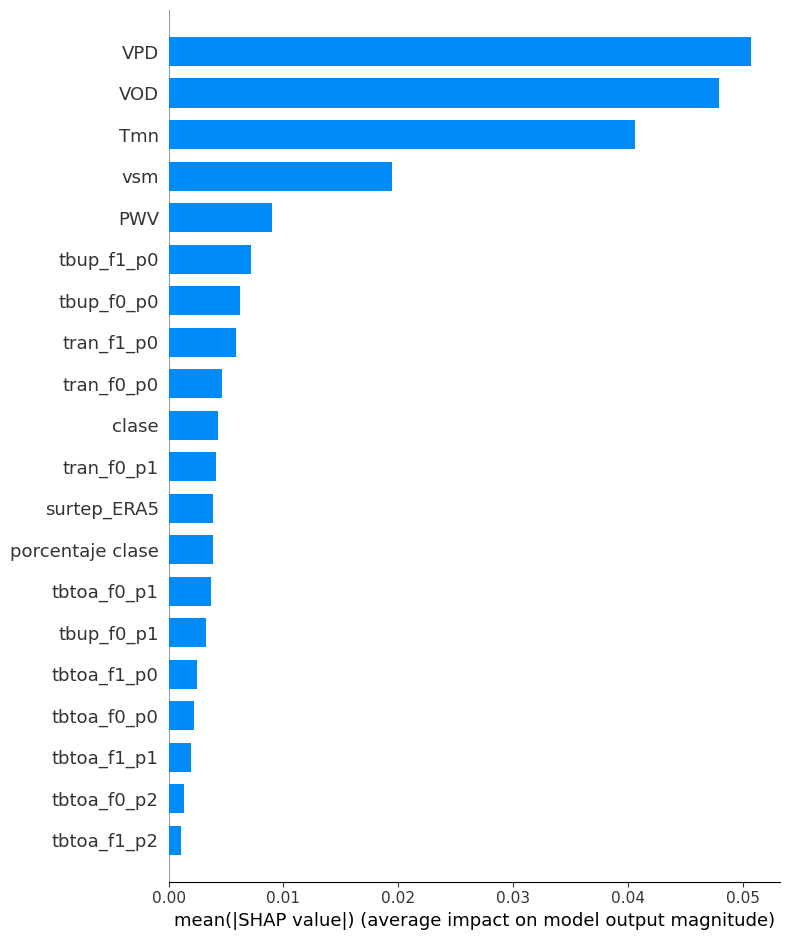

In [10]:
# Remove last column (bias) if you want just feature contributions
shap_values_features = shap_values[:, :-1]

shap.summary_plot(
    shap_values_features,
    X_test,
    plot_type="bar",
    show=True
)